## CLUSTERING ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df=pd.read_excel('EastWestAirlines.xlsx',1)
df.shape

(3999, 12)

In [3]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


### Data Preprocessing:

In [4]:
features=df.drop(columns=['ID#'])

In [5]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


In [6]:
features.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
## missing values
features.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [8]:
## duplicate value
features.duplicated().sum()

np.int64(1)

<Axes: >

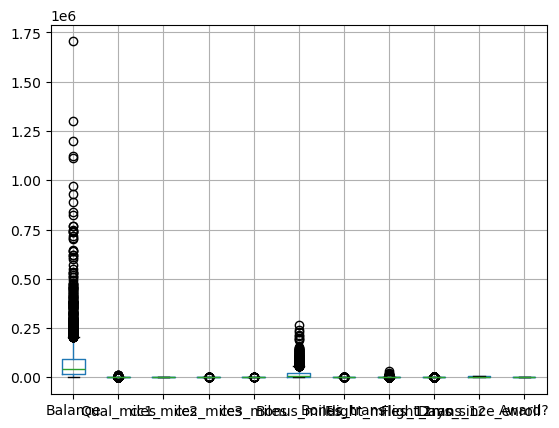

In [9]:
## outliers
features.boxplot()

In [10]:
## outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in features.columns:
    outlier_capping(features,col)

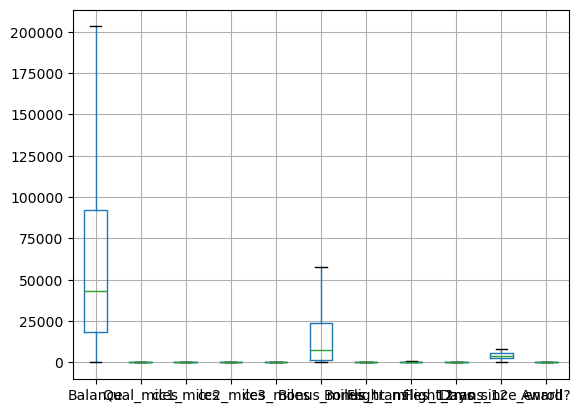

In [11]:
## outliers
features.boxplot()
plt.show()

In [12]:
## drop columns containing only zero
features.drop(columns=['Qual_miles','cc2_miles','cc3_miles'],inplace=True)
features.head()

,Balance,cc1_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143.0,1,174.0,1.0,0.0,0.0,7000,0
1,19244.0,1,215.0,2.0,0.0,0.0,6968,0
2,41354.0,1,4123.0,4.0,0.0,0.0,7034,0
3,14776.0,1,500.0,1.0,0.0,0.0,6952,0
4,97752.0,4,43300.0,26.0,777.5,2.5,6935,1


In [13]:
## scaling
std_sca=StandardScaler()
features=pd.DataFrame(std_sca.fit_transform(features),columns=features.columns)

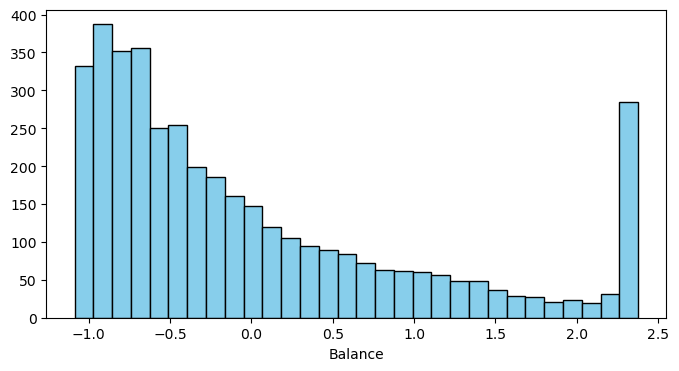

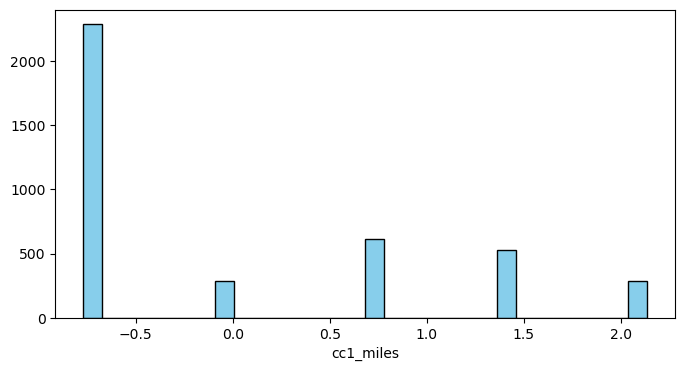

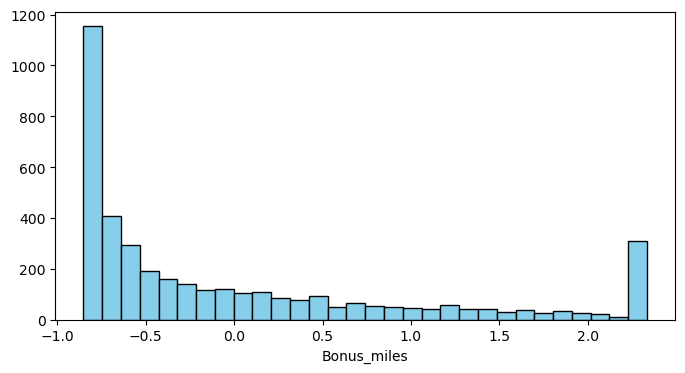

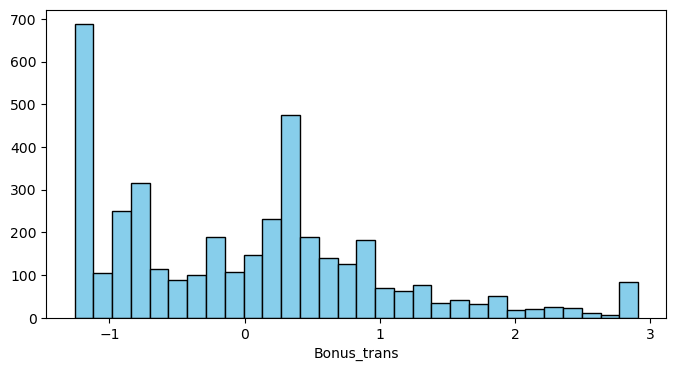

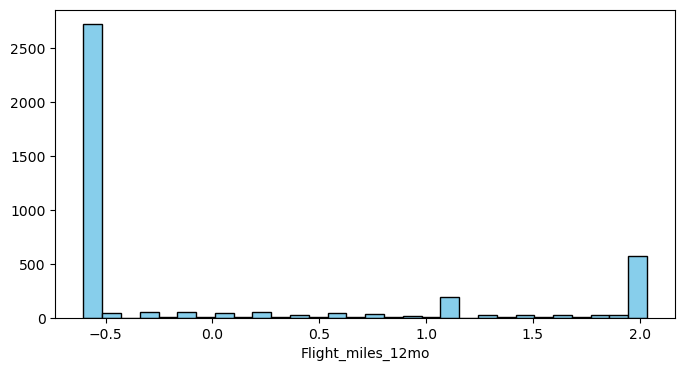

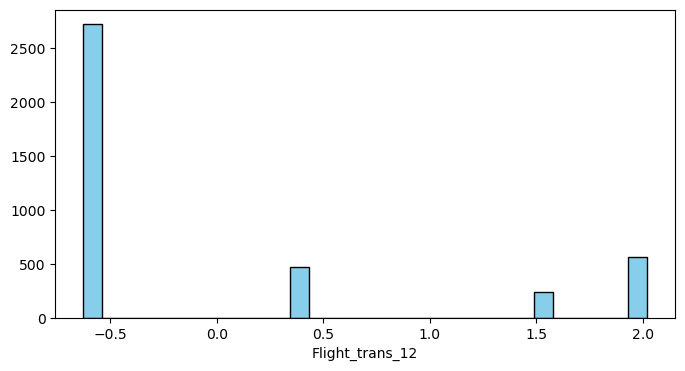

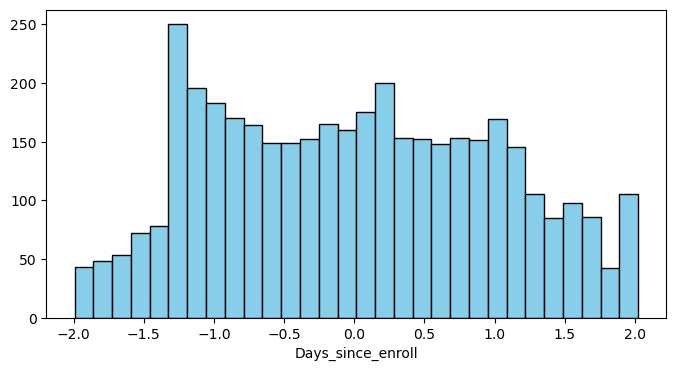

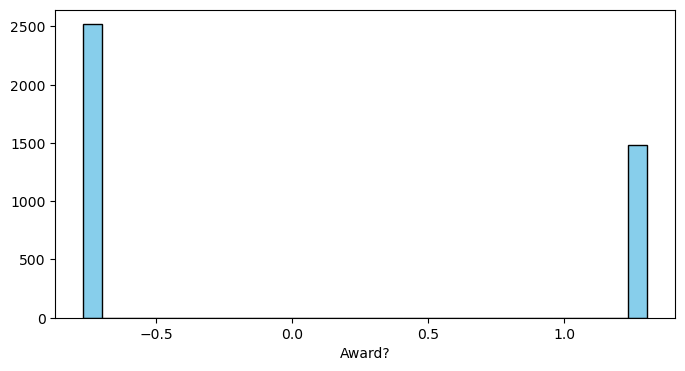

In [14]:
## histogram for features distribution
for col in features:
    plt.figure(figsize=(8, 4))
    plt.hist(features[col], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.show()

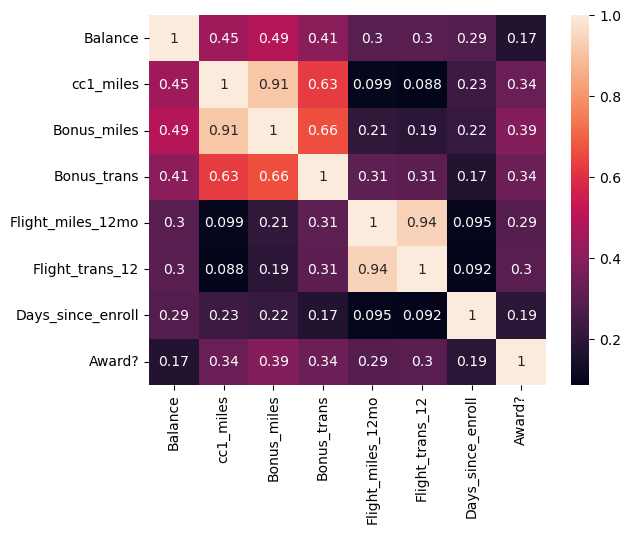

In [15]:
corr=features.corr()
sns.heatmap(corr,annot=True)
plt.show()

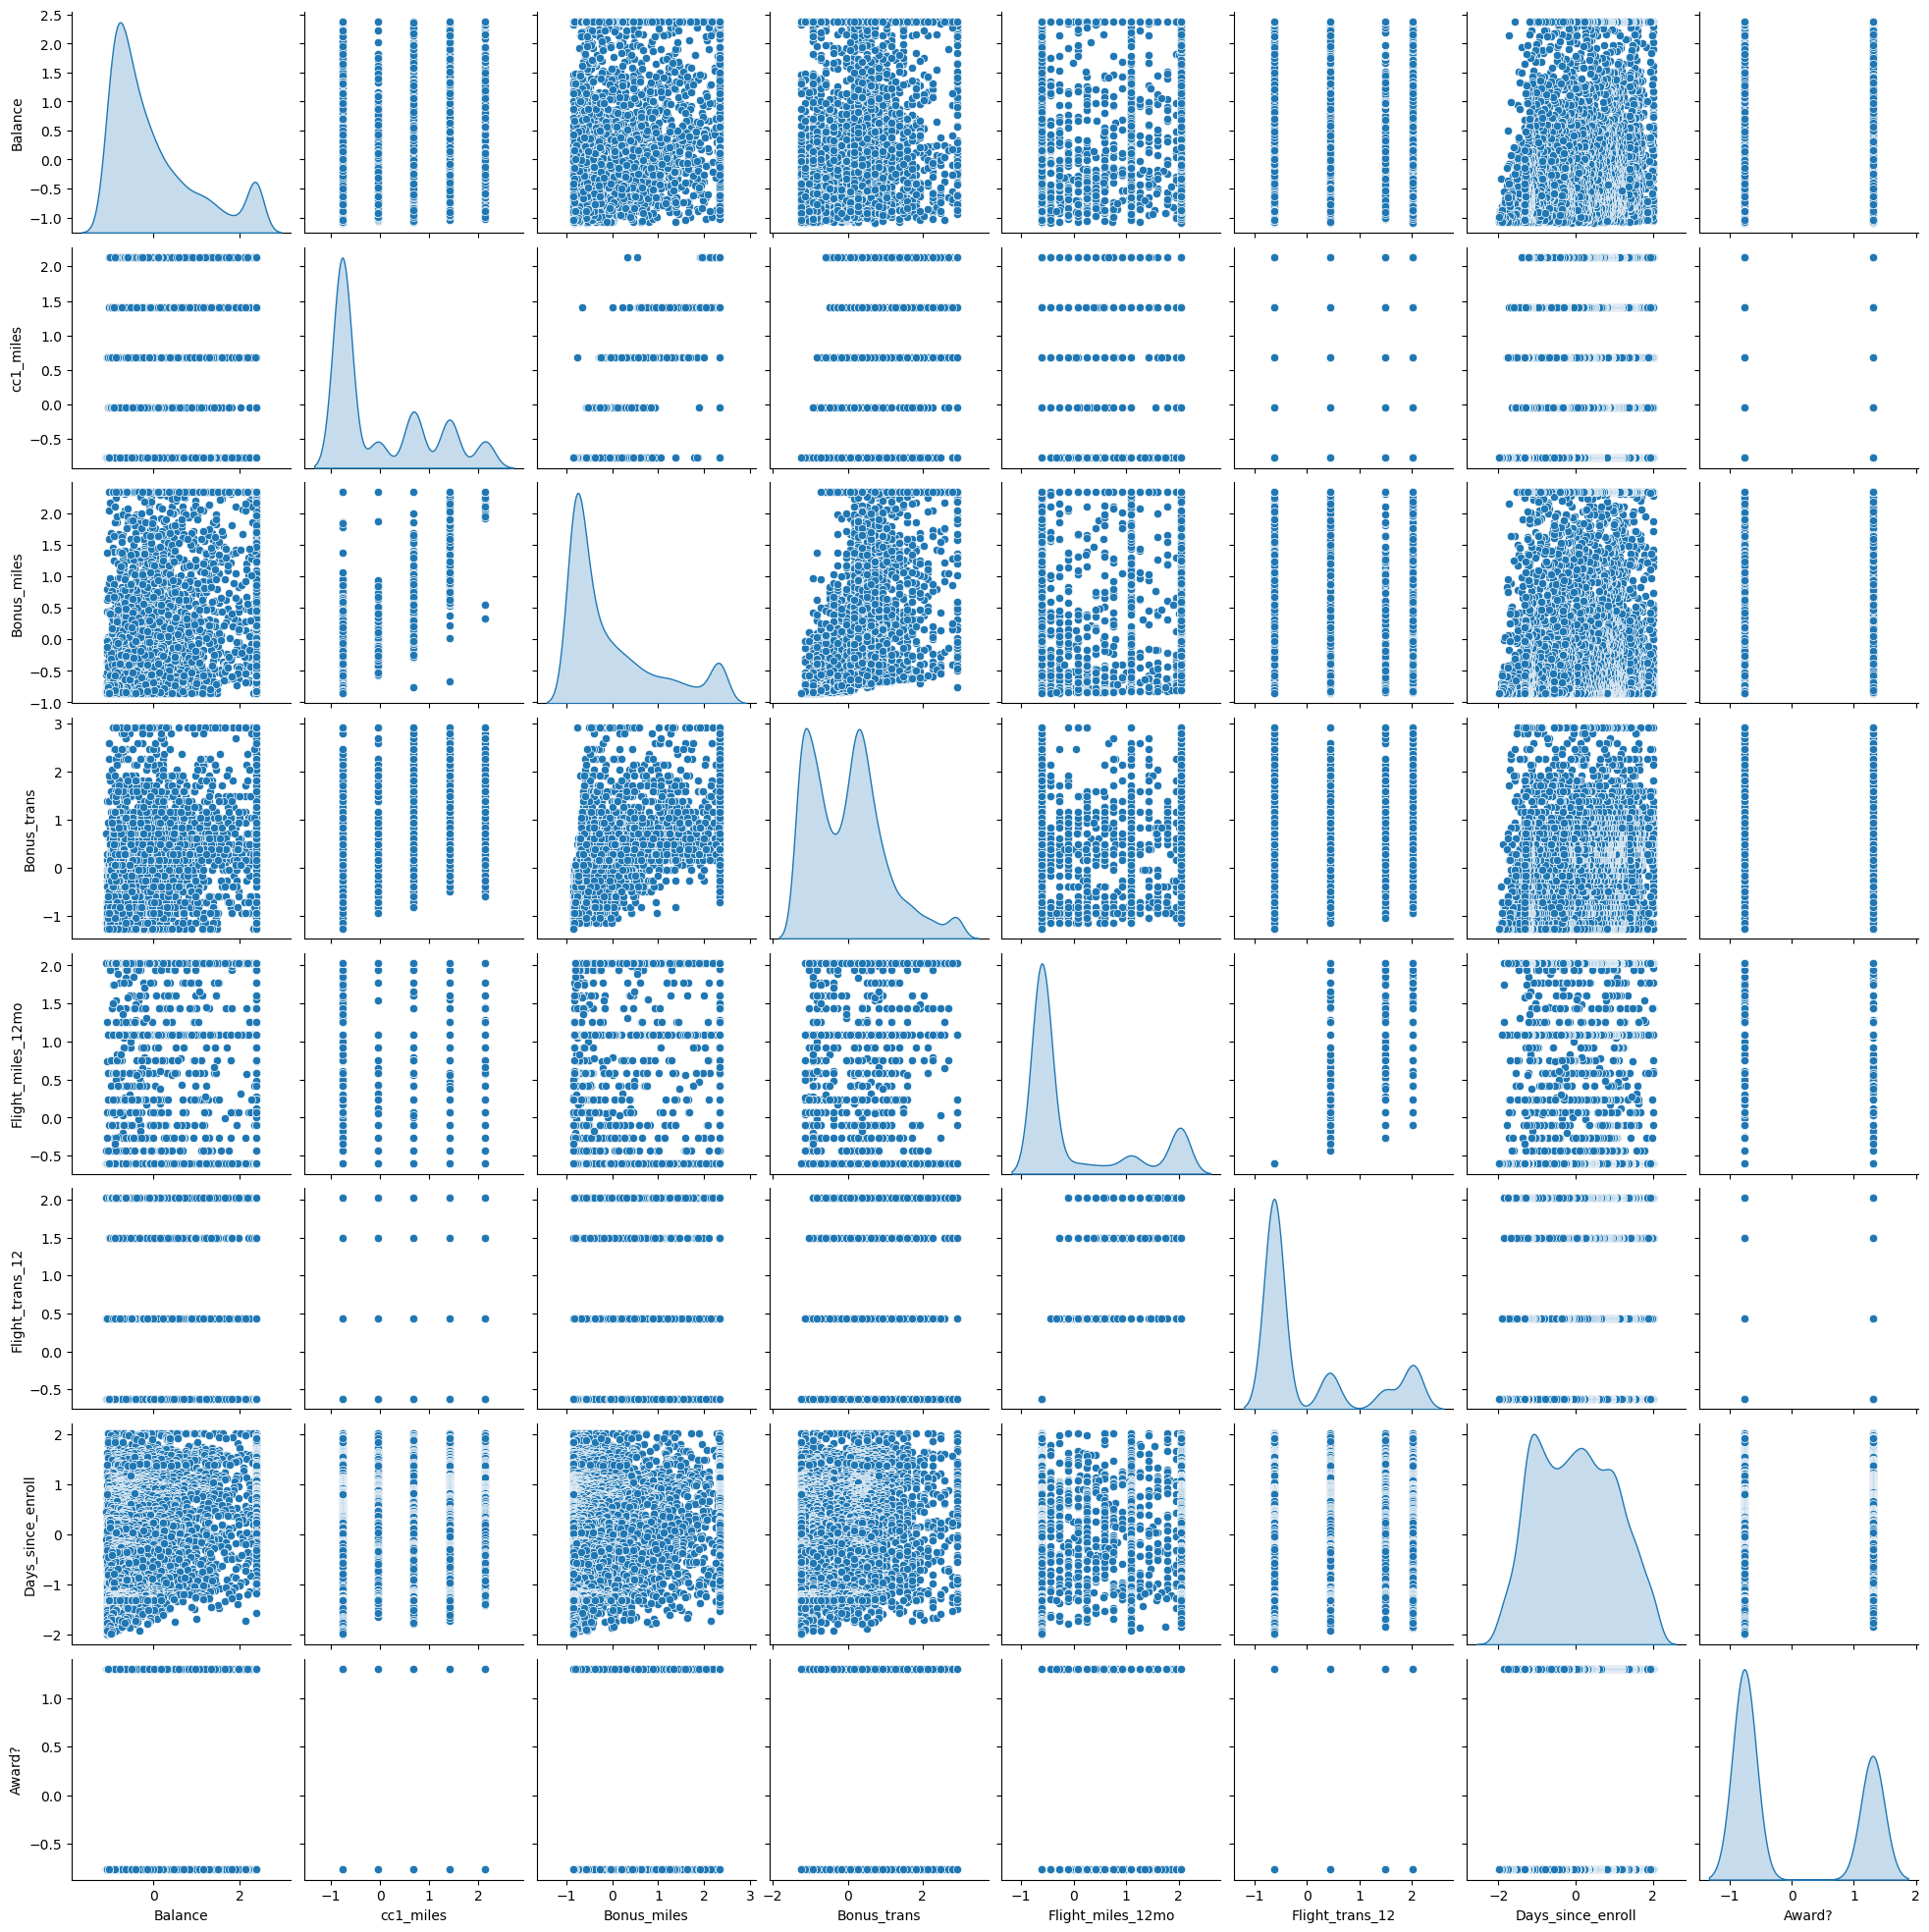

In [16]:
sns.pairplot(features, diag_kind="kde")
plt.show()

In [17]:
## pca for finding hidden patterns
pca = PCA(n_components=2)
pca_data = pca.fit_transform(features)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

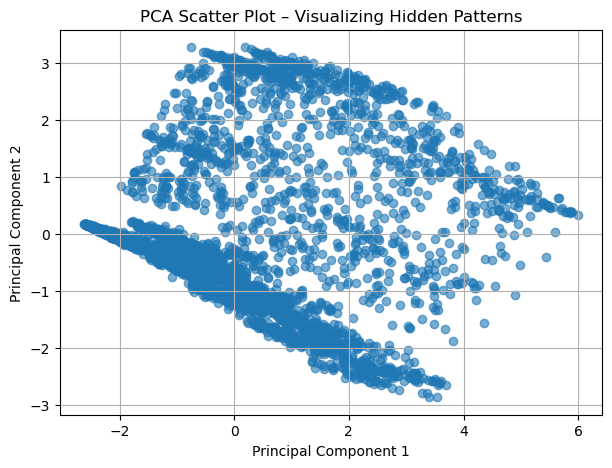

In [18]:
# Plot
plt.figure(figsize=(7,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.title("PCA Scatter Plot – Visualizing Hidden Patterns")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Implementing Clustering Algorithms:

##### KMEANS

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [20]:
kmeans=KMeans(n_clusters=5)
clusters=kmeans.fit(features)

In [21]:
print(kmeans.inertia_)
print(np.unique(clusters.labels_))

13809.86245783902
[0 1 2 3 4]


In [22]:
features['cluster']=clusters.labels_

In [23]:
silhouette_score(features.drop(columns=['cluster']),clusters.labels_)

np.float64(0.2955248957231654)

In [24]:
## elbow method

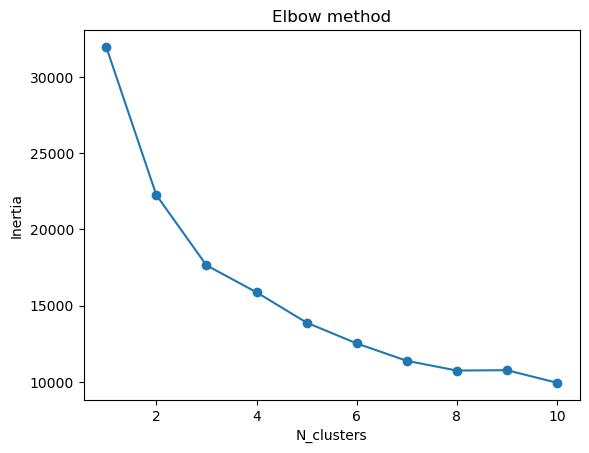

In [25]:
features_elbow = features.drop(columns=['cluster'], errors='ignore')
inertia=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(features_elbow)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,11),inertia, marker='o')
plt.xlabel('N_clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

In [26]:
kmeans=KMeans(n_clusters=3)
clusters=kmeans.fit(features_elbow)

In [27]:
silhouette_score(features_elbow,clusters.labels_)

np.float64(0.30871467844360884)

##### DBSCAN

In [85]:
from sklearn.cluster import DBSCAN

In [104]:
feature= features.drop(columns=['cluster'], errors='ignore')
eps_values = np.arange(0.1, 1.0, 0.1)
min_samples_values = range(1, 11)

In [105]:
output = []
n = len(feature)
for e in eps_values:
    for m in min_samples_values:
        db = DBSCAN(eps=e, min_samples=m)
        labels = db.fit_predict(feature)
        noise_ratio = list(labels).count(-1)/n
        # reject eps values with excessive noise
        if noise_ratio > 0.30:  
            continue   
        # Must form at least 2 clusters
        if len(set(labels) - {-1}) < 2:
            continue
        # mask out noise points
        mask = labels != -1
        valid_labels = labels[mask]
        valid_data = feature[mask]
        score = silhouette_score(valid_data, valid_labels)
        output.append([e, m, score])

In [106]:
a = pd.DataFrame(output, columns=['eps', 'min_samples', 'score'])
sil_score = a['score'].max()
print("Best Silhouette Score:", sil_score)
print(a[a.score == sil_score])

Best Silhouette Score: 0.11062005282467909
    eps  min_samples    score
15  0.7            6  0.11062


In [107]:
labels = DBSCAN(eps=0.7, min_samples=6).fit_predict(feature)
print(np.unique(labels))
print("Noise:", list(labels).count(-1))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31]
Noise: 1157


In [110]:
dbscan = DBSCAN(eps=0.7, min_samples=6)
dbscan_labels = dbscan.fit_predict(feature)
feature['DBSCAN_cluster'] = dbscan_labels

##### Hierarchical

In [116]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [120]:
feature_h=feature.drop(columns=['DBSCAN_cluster'], errors='ignore')

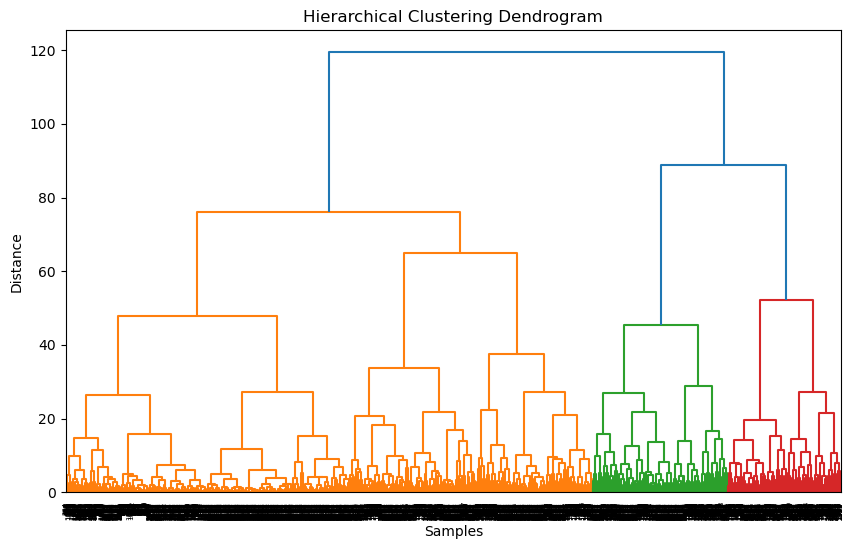

In [124]:
# Dendrogram
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram")
dendrogram(linkage(feature_h, method='ward'))
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [128]:
# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(feature_h)

In [127]:
# Silhouette score
hc_score = silhouette_score(feature_h, labels_hc)
hc_score

np.float64(0.25553610801899945)

### Cluster Analysis and Interpretation:

### Visualization:

In [34]:
## KMEANS

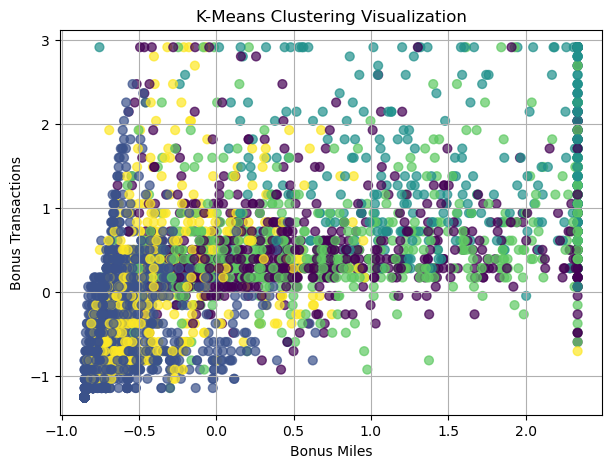

In [112]:
plt.figure(figsize=(7,5))
plt.scatter(
    features['Bonus_miles'], 
    features['Bonus_trans'],
    c=features['cluster'],    # or 'cluster_4' or your final K-Means column
    cmap='viridis',
    s=40,
    alpha=0.7
)
plt.xlabel("Bonus Miles")
plt.ylabel("Bonus Transactions")
plt.title("K-Means Clustering Visualization")
plt.grid(True)
plt.show()

In [37]:
## DBSCAN

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

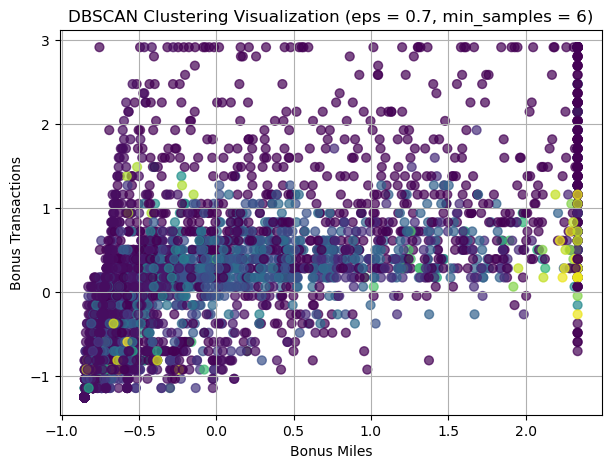

In [115]:
plt.figure(figsize=(7,5))
plt.scatter(
    feature['Bonus_miles'],
    feature['Bonus_trans'],
    c=feature['DBSCAN_cluster'], 
    cmap='viridis',
    s=40,
    alpha=0.7
)
plt.xlabel("Bonus Miles")
plt.ylabel("Bonus Transactions")
plt.title("DBSCAN Clustering Visualization (eps = 0.7, min_samples = 6)")
plt.grid(True)
plt.show()


In [ ]:
## Hierarchical

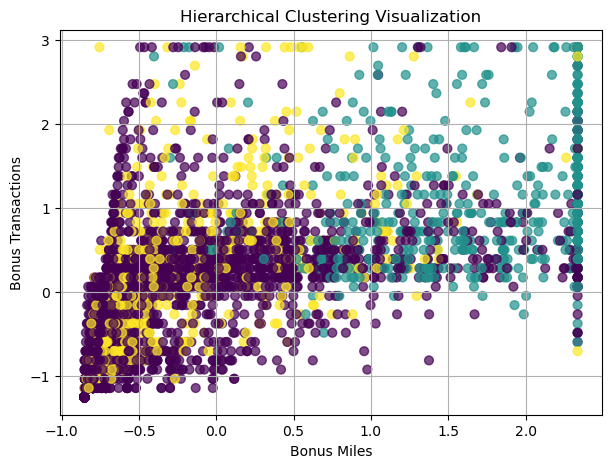

In [129]:
plt.figure(figsize=(7,5))
plt.scatter(
    features_elbow['Bonus_miles'],
    features_elbow['Bonus_trans'],
    c=labels_hc,
    cmap='viridis',
    s=40,
    alpha=0.7
)
plt.xlabel("Bonus Miles")
plt.ylabel("Bonus Transactions")
plt.title("Hierarchical Clustering Visualization")
plt.grid(True)
plt.show()

### Evaluation and Performance Metrics: